In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson

In [50]:
cs = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/DataExport_office_v2.xlsx')
ff = pd.read_excel('../data/FEDFUNDS (1).xlsx')
bond = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/bond_yield_10yr.xlsx')
rrp = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/real_risk_premieum.csv')
inf_e = pd.read_excel('/Users/elyas/vscode/market_analysis_03_office/data/Inflation expectations (1).xlsx')
cmbs = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/commercial_mortgage.csv')
gdp = pd.read_csv('/Users/elyas/vscode/market_analysis_03_office/data/GDP.csv')

#create a subset where column Population is greater than 500000
cs = cs[cs['Population'] > 500000]

#convert to time series
def convert_period_to_datetime(period):
	parts = period.split('Q')
	year = parts[0].strip()
	quarter = parts[1].strip().split()[0]
	month = (int(quarter) - 1) * 3 + 1
	return pd.Timestamp(year=int(year), month=month, day=1)

cs['Period'] = cs['Period'].apply(convert_period_to_datetime)

#remove periods in the year 2025
cs = cs[cs['Period'].dt.year != 2025]

#get data only where geography has Atlanta
cs = cs[cs['Geography Name'].str.contains('Atlanta')]



In [51]:
inf_e.tail()

,Model Output Date,one_yr_inf_exp,two_yr_inf_exp,three_yr_inf_exp,four_yr_inf_exp,five_yr_inf_exp,six_yr_inf_exp,seven_yr_inf_exp,eight_yr_inf_exp,nine_yr_inf_exp,ten_yr_inf_exp
513,2024-10-01,0.022561,0.022051,0.021563,0.021249,0.021074,0.020997,0.020985,0.021018,0.021080,0.021163
514,2024-11-01,0.024317,0.024026,0.023689,0.023461,0.023327,0.023259,0.023237,0.023247,0.023277,0.023322
515,2024-12-01,0.026504,0.025005,0.024224,0.023768,0.023497,0.023341,0.023258,0.023224,0.023223,0.023245
516,2025-01-01,0.026270,0.025499,0.025041,0.024762,0.024594,0.024496,0.024445,0.024426,0.024427,0.024443
517,2025-02-01,0.027322,0.026075,0.025453,0.025093,0.024875,0.024745,0.024669,0.024630,0.024617,0.024620


In [52]:
cmbs.tail()

,observation_date,ASCMA
94,2023-07-01,3736667
95,2023-10-01,3761196
96,2024-01-01,3783601
97,2024-04-01,3793932
98,2024-07-01,3813202


In [53]:
#change the column name to period
cmbs.rename(columns={'observation_date': 'period'}, inplace=True)
gdp.rename(columns={'observation_date': 'period'}, inplace=True)
cmbs.rename(columns={'ASCMA': 'oustanding_mortgage'}, inplace=True)
gdp.rename(columns={'GDP': 'gdp'}, inplace=True)
rrp.rename(columns={'observation_date': 'period'}, inplace=True)
inf_e.rename(columns={'Model Output Date': 'period'}, inplace=True)


#the units in outstanding mortgage is in millions, let's convert it to billions
cmbs['oustanding_mortgage'] = cmbs['oustanding_mortgage'] / 1000

#create a new column in cmbs called cmbs_to_gdp
cmbs['cmbs_to_gdp'] = cmbs['oustanding_mortgage'] / gdp['gdp']


In [54]:
inf_e.tail()

,period,one_yr_inf_exp,two_yr_inf_exp,three_yr_inf_exp,four_yr_inf_exp,five_yr_inf_exp,six_yr_inf_exp,seven_yr_inf_exp,eight_yr_inf_exp,nine_yr_inf_exp,ten_yr_inf_exp
513,2024-10-01,0.022561,0.022051,0.021563,0.021249,0.021074,0.020997,0.020985,0.021018,0.021080,0.021163
514,2024-11-01,0.024317,0.024026,0.023689,0.023461,0.023327,0.023259,0.023237,0.023247,0.023277,0.023322
515,2024-12-01,0.026504,0.025005,0.024224,0.023768,0.023497,0.023341,0.023258,0.023224,0.023223,0.023245
516,2025-01-01,0.026270,0.025499,0.025041,0.024762,0.024594,0.024496,0.024445,0.024426,0.024427,0.024443
517,2025-02-01,0.027322,0.026075,0.025453,0.025093,0.024875,0.024745,0.024669,0.024630,0.024617,0.024620


In [55]:
ff.tail()

,period,fed_funds_rate
295,2024-08-01,5.33
296,2024-09-01,5.13
297,2024-10-01,4.83
298,2024-11-01,4.64
299,2024-12-01,4.48


In [56]:
#convert real risk premieum to quarterly
ff['period'] = pd.to_datetime(ff['period'])
ff.set_index('period', inplace=True)
ff = ff.resample('Q').mean()
#each data should start on first of the quarter
ff.index = ff.index.to_period('Q').start_time
#change the column period from index to column
ff.reset_index(inplace=True)



/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_6174/4267819200.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ff = ff.resample('Q').mean()


In [57]:
inf_e.head()

,period,one_yr_inf_exp,two_yr_inf_exp,three_yr_inf_exp,four_yr_inf_exp,five_yr_inf_exp,six_yr_inf_exp,seven_yr_inf_exp,eight_yr_inf_exp,nine_yr_inf_exp,ten_yr_inf_exp
0,1982-01-01,0.063945,0.064520,0.064968,0.065031,0.064809,0.064401,0.063876,0.063278,0.062639,0.061976
1,1982-02-01,0.064321,0.064729,0.064764,0.064502,0.064049,0.063482,0.062847,0.062176,0.061487,0.060792
2,1982-03-01,0.063877,0.062955,0.062026,0.061133,0.060277,0.059457,0.058669,0.057912,0.057183,0.056481
3,1982-04-01,0.061406,0.062227,0.061916,0.061328,0.060649,0.059938,0.059222,0.058512,0.057814,0.057132
4,1982-05-01,0.054882,0.058522,0.059484,0.059638,0.059439,0.059059,0.058579,0.058044,0.057479,0.056900


In [58]:
#convert real risk premieum to quarterly
inf_e['period'] = pd.to_datetime(inf_e['period'])
inf_e.set_index('period', inplace=True)
inf_e = inf_e.resample('Q').mean()
#change the variable TENEXPCHAREARISPRE to ten_yr_risk_premium
#inf_e.rename(columns={'TENEXPCHAREARISPRE': 'ten_yr_risk_premium'}, inplace=True)
#each data should start on first of the quarter
inf_e.index = inf_e.index.to_period('Q').start_time
#change the column period from index to column
inf_e.reset_index(inplace=True)



/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_6174/2376250054.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  inf_e = inf_e.resample('Q').mean()


In [59]:
#convert real risk premieum to quarterly
rrp['period'] = pd.to_datetime(rrp['period'])
rrp.set_index('period', inplace=True)
rrp = rrp.resample('Q').mean()
#change the variable TENEXPCHAREARISPRE to ten_yr_risk_premium
rrp.rename(columns={'TENEXPCHAREARISPRE': 'ten_yr_risk_premium'}, inplace=True)
#each data should start on first of the quarter
rrp.index = rrp.index.to_period('Q').start_time
#change the column period from index to column
rrp.reset_index(inplace=True)


/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_6174/850413121.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  rrp = rrp.resample('Q').mean()


In [60]:
#get data from 2000
inf_e = inf_e[inf_e['period'] >= '2000-01-01']

In [61]:
#Get the data we want

cs = cs[
    [
        "Geography Name",
        "Period",
        "Appreciation Return",
        "Availability Rate",
        "Available SF Direct",
        "Average Sale Price",
        "Cap Rate",
        "Market Cap Rate",
        "Construction Starts SF",
        "Construction Starts SF 12 Mo",
        "Demand SF",
        "Demolished SF",
        "Gross Delivered SF",
        "Inventory SF",
        "Leasing SF Total",
        "Market Asking Rent Growth",
        "Market Asking Rent Growth 12 Mo",
        "Net Absorption SF",
        "Net Absorption SF 12 Mo",
        "Net Delivered SF",
        "Net Delivered SF 12 Mo",
        "Occupancy Rate",
        "Sales Volume Transactions",
        "Sold Building SF",
        "Vacancy Rate",
        "Under Construction SF",
        "Total Sales Transactions"
    ]
].copy()

# Next, rename columns
cs.rename(
    columns={
        "Geography Name": "geography",
        "Period": "period",
        "Appreciation Return": "appreciation_return",
        "Availability Rate": "availability_rate",
        "Available SF Direct": "available_df_direct",
        "Average Sale Price": "avg_sale_price",
        "Cap Rate": "cap_rate",
        "Market Cap Rate": "market_cap_rate",
        "Construction Starts SF": "starts_sf",
        "Construction Starts SF 12 Mo": "starts_sf_12_mo",
        "Demand SF": "demand_sf",
        "Demolished SF": "demolished_sf",
        "Gross Delivered SF": "gross_delivered_sf",
        "Inventory SF": "inventory_sf",
        "Leasing SF Total": "leasing_sf_total",
        "Market Asking Rent Growth": "asking_rent_growth",
        "Market Asking Rent Growth 12 Mo": "asking_rent_growth_12_mo",
        "Net Absorption SF": "net_absorp_sf",
        "Net Absorption SF 12 Mo": "net_absorp_sf_12_mo",
        "Net Delivered SF": "net_delivered_sf",
        "Net Delivered SF 12 Mo": "net_delivered_sf_12_mo",
        "Occupancy Rate": "occupancy_rate",
        "Sales Volume Transactions": "sales_volume",
        "Sold Building SF": "sold_building_sf",
        "Vacancy Rate": "vacancy_rate",
        "Under Construction SF": "under_construction_sf",
        "Total Sales Transactions": "total_sales_transactions"
    },
    inplace=True
)


In [62]:
cs.dtypes

geography                           object
period                      datetime64[ns]
appreciation_return                float64
availability_rate                  float64
available_df_direct                float64
avg_sale_price                     float64
cap_rate                           float64
market_cap_rate                    float64
starts_sf                          float64
starts_sf_12_mo                    float64
demand_sf                          float64
demolished_sf                      float64
gross_delivered_sf                 float64
inventory_sf                         int64
leasing_sf_total                   float64
asking_rent_growth                 float64
asking_rent_growth_12_mo           float64
net_absorp_sf                      float64
net_absorp_sf_12_mo                float64
net_delivered_sf                   float64
net_delivered_sf_12_mo               int64
occupancy_rate                     float64
sales_volume                       float64
sold_buildi

In [63]:
### merge datasets

cmbs['period'] = pd.to_datetime(cmbs['period'])
cs = pd.merge(cs, bond, on='period', how='left')
cs = pd.merge(cs, inf_e, on='period', how='left')
cs = pd.merge(cs, rrp, on='period', how='left')
cs = pd.merge(cs, ff, on='period', how='left')
cs = pd.merge(cs, cmbs[['period', 'cmbs_to_gdp']], on='period', how='left')
cs = pd.merge(cs, bond, on='period', how='left')


In [65]:
cs['eight_yr_inf_exp']

0     0.033285
1     0.032767
2     0.030588
3     0.029410
4     0.025458
        ...   
95    0.023488
96    0.021665
97    0.023925
98    0.022112
99    0.022496
Name: eight_yr_inf_exp, Length: 100, dtype: float64

In [66]:
#convert variables to percentage
#multiply by 100 availability rate
cs['availability'] = cs['availability_rate'] * 100
cs['cap_rate'] = cs['cap_rate'] * 100
cs['market_cap_rate'] = cs['market_cap_rate'] * 100
cs['asking_rent_growth'] = cs['asking_rent_growth'] * 100
cs['asking_rent_growth_12_mo'] = cs['asking_rent_growth_12_mo'] * 100
cs['occupancy_rate'] = cs['occupancy_rate'] * 100
cs['vacancy_rate'] = cs['vacancy_rate'] * 100
cs['appreciation_return'] = cs['appreciation_return'] * 100
cs['one_yr_inf_exp'] = cs['one_yr_inf_exp'] * 100
cs['two_yr_inf_exp'] = cs['two_yr_inf_exp'] * 100
cs['three_yr_inf_exp'] = cs['three_yr_inf_exp'] * 100
cs['four_yr_inf_exp'] = cs['four_yr_inf_exp'] * 100
cs['five_yr_inf_exp'] = cs['five_yr_inf_exp'] * 100
cs['six_yr_inf_exp'] = cs['six_yr_inf_exp'] * 100
cs['seven_yr_inf_exp'] = cs['seven_yr_inf_exp'] * 100
cs['eight_yr_inf_exp'] = cs['eight_yr_inf_exp'] * 100
cs['nine_yr_inf_exp'] = cs['nine_yr_inf_exp'] * 100
cs['ten_yr_inf_exp'] = cs['ten_yr_inf_exp'] * 100
cs['cmbs_to_gdp'] = cs['cmbs_to_gdp'] * 100


In [45]:
cs.head()

,geography,period,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,...,six_yr_inf_exp,seven_yr_inf_exp,eight_yr_inf_exp,nine_yr_inf_exp,ten_yr_inf_exp,ten_yr_risk_premium,fed_funds_rate,cmbs_to_gdp,bond_yield_10yr_y,availability
0,Atlanta - GA USA,2000-01-01,1.996212,NaN,NaN,5662759.0,9.864546,9.707598,3513818.0,13834133.0,...,3.334707,3.332517,3.328459,3.323236,3.317285,1.321698,5.676667,10.858744,6.480000,NaN
1,Atlanta - GA USA,2000-04-01,0.029603,NaN,NaN,4170181.0,10.243572,9.737211,3087883.0,12950512.0,...,3.296978,3.286445,3.276708,3.267590,3.258982,1.240777,6.273333,10.895663,6.176667,NaN
2,Atlanta - GA USA,2000-07-01,-0.951823,NaN,NaN,3275183.0,10.488000,9.913068,4253537.0,13824219.0,...,3.074912,3.066052,3.058823,3.052792,3.047656,1.187069,6.520000,11.034501,5.893333,NaN
3,Atlanta - GA USA,2000-10-01,-2.447272,NaN,NaN,4558434.0,10.368750,9.950081,2549278.0,13404516.0,...,2.959286,2.948705,2.940997,2.935303,2.931051,1.176115,6.473333,11.178302,5.566667,NaN
4,Atlanta - GA USA,2001-01-01,-3.037886,NaN,NaN,1512973.0,10.986154,10.011605,1146188.0,11036886.0,...,2.538486,2.541324,2.545846,2.551512,2.557932,1.138131,5.593333,10.963645,5.050000,NaN


In [46]:
#printt the number of missing values for each column
print(cs.isnull().sum())

#print row where cmbs_to_gdp is null
print(cs[cs['cmbs_to_gdp'].isnull()])

#print the period where cmbs_to_gdp is null
print(cs[cs['fed_funds_rate'].isnull()]['period'])

geography                    0
period                       0
appreciation_return          0
availability_rate           21
available_df_direct         21
avg_sale_price               0
cap_rate                     1
market_cap_rate              0
starts_sf                    0
starts_sf_12_mo              0
demand_sf                    0
demolished_sf                0
gross_delivered_sf           0
inventory_sf                 0
leasing_sf_total             0
asking_rent_growth           0
asking_rent_growth_12_mo     0
net_absorp_sf                0
net_absorp_sf_12_mo          0
net_delivered_sf             0
net_delivered_sf_12_mo       0
occupancy_rate               0
sales_volume                 0
sold_building_sf             0
vacancy_rate                 0
under_construction_sf        0
total_sales_transactions     0
bond_yield_10yr_x            0
one_yr_inf_exp               0
two_yr_inf_exp               0
three_yr_inf_exp             0
four_yr_inf_exp              0
five_yr_

### Standardize the data

In [47]:
#drop the geography column and convert period into a dateime index
cs.drop(columns=['geography'], inplace=True)
cs.set_index('period', inplace=True)


In [48]:
#export data to csv
cs.to_csv('/Users/elyas/vscode/market_analysis_03_office/data/preprocessed_not_standardized.csv')

In [20]:
#normalize the entire dataset using the z-score method, the index column should be left alone
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cs_scaled = scaler.fit_transform(cs)
cs_scaled = pd.DataFrame(cs_scaled, columns=cs.columns, index=cs.index)
cs_scaled.head()

,appreciation_return,availability_rate,available_df_direct,avg_sale_price,cap_rate,market_cap_rate,starts_sf,starts_sf_12_mo,demand_sf,demolished_sf,...,six_yr_inf_exp,seven_yr_inf_exp,eight_yr_inf_exp,nine_yr_inf_exp,ten_yr_inf_exp,ten_yr_risk_premium,fed_funds_rate,cmbs_to_gdp,bond_yield_10yr_y,availability
period,,,,,,,,,,,,,,,,,,,,,
2000-01-01,0.363376,NaN,NaN,0.681921,1.380240,1.743901,3.041288,3.292431,-2.173649,-0.660495,...,2.851996,2.881925,2.902997,2.918305,2.929650,1.331228,1.865409,-1.941666,2.479000,NaN
2000-04-01,0.078773,NaN,NaN,0.055957,1.742132,1.778370,2.535278,2.996354,-1.869876,-0.660495,...,2.771205,2.780898,2.786858,2.790544,2.792742,0.209934,2.161659,-1.918510,2.243744,NaN
2000-07-01,-0.063257,NaN,NaN,-0.319392,1.975511,1.983072,3.920072,3.289110,-2.002496,-0.660495,...,2.295675,2.297621,2.297886,2.297380,2.296503,-0.534271,2.284130,-1.831429,2.024000,NaN
2000-10-01,-0.279675,NaN,NaN,0.218784,1.861652,2.026157,1.895416,3.148478,-1.844696,-0.479620,...,2.048075,2.040303,2.033463,2.027630,2.022688,-0.686063,2.260960,-1.741235,1.770648,NaN
2001-01-01,-0.365147,NaN,NaN,-1.058435,2.451147,2.097772,0.228548,2.355149,-1.811095,-0.489365,...,1.146982,1.147001,1.146672,1.146466,1.146525,-1.212397,1.824034,-1.875871,1.369938,NaN


### Correlation Analysis

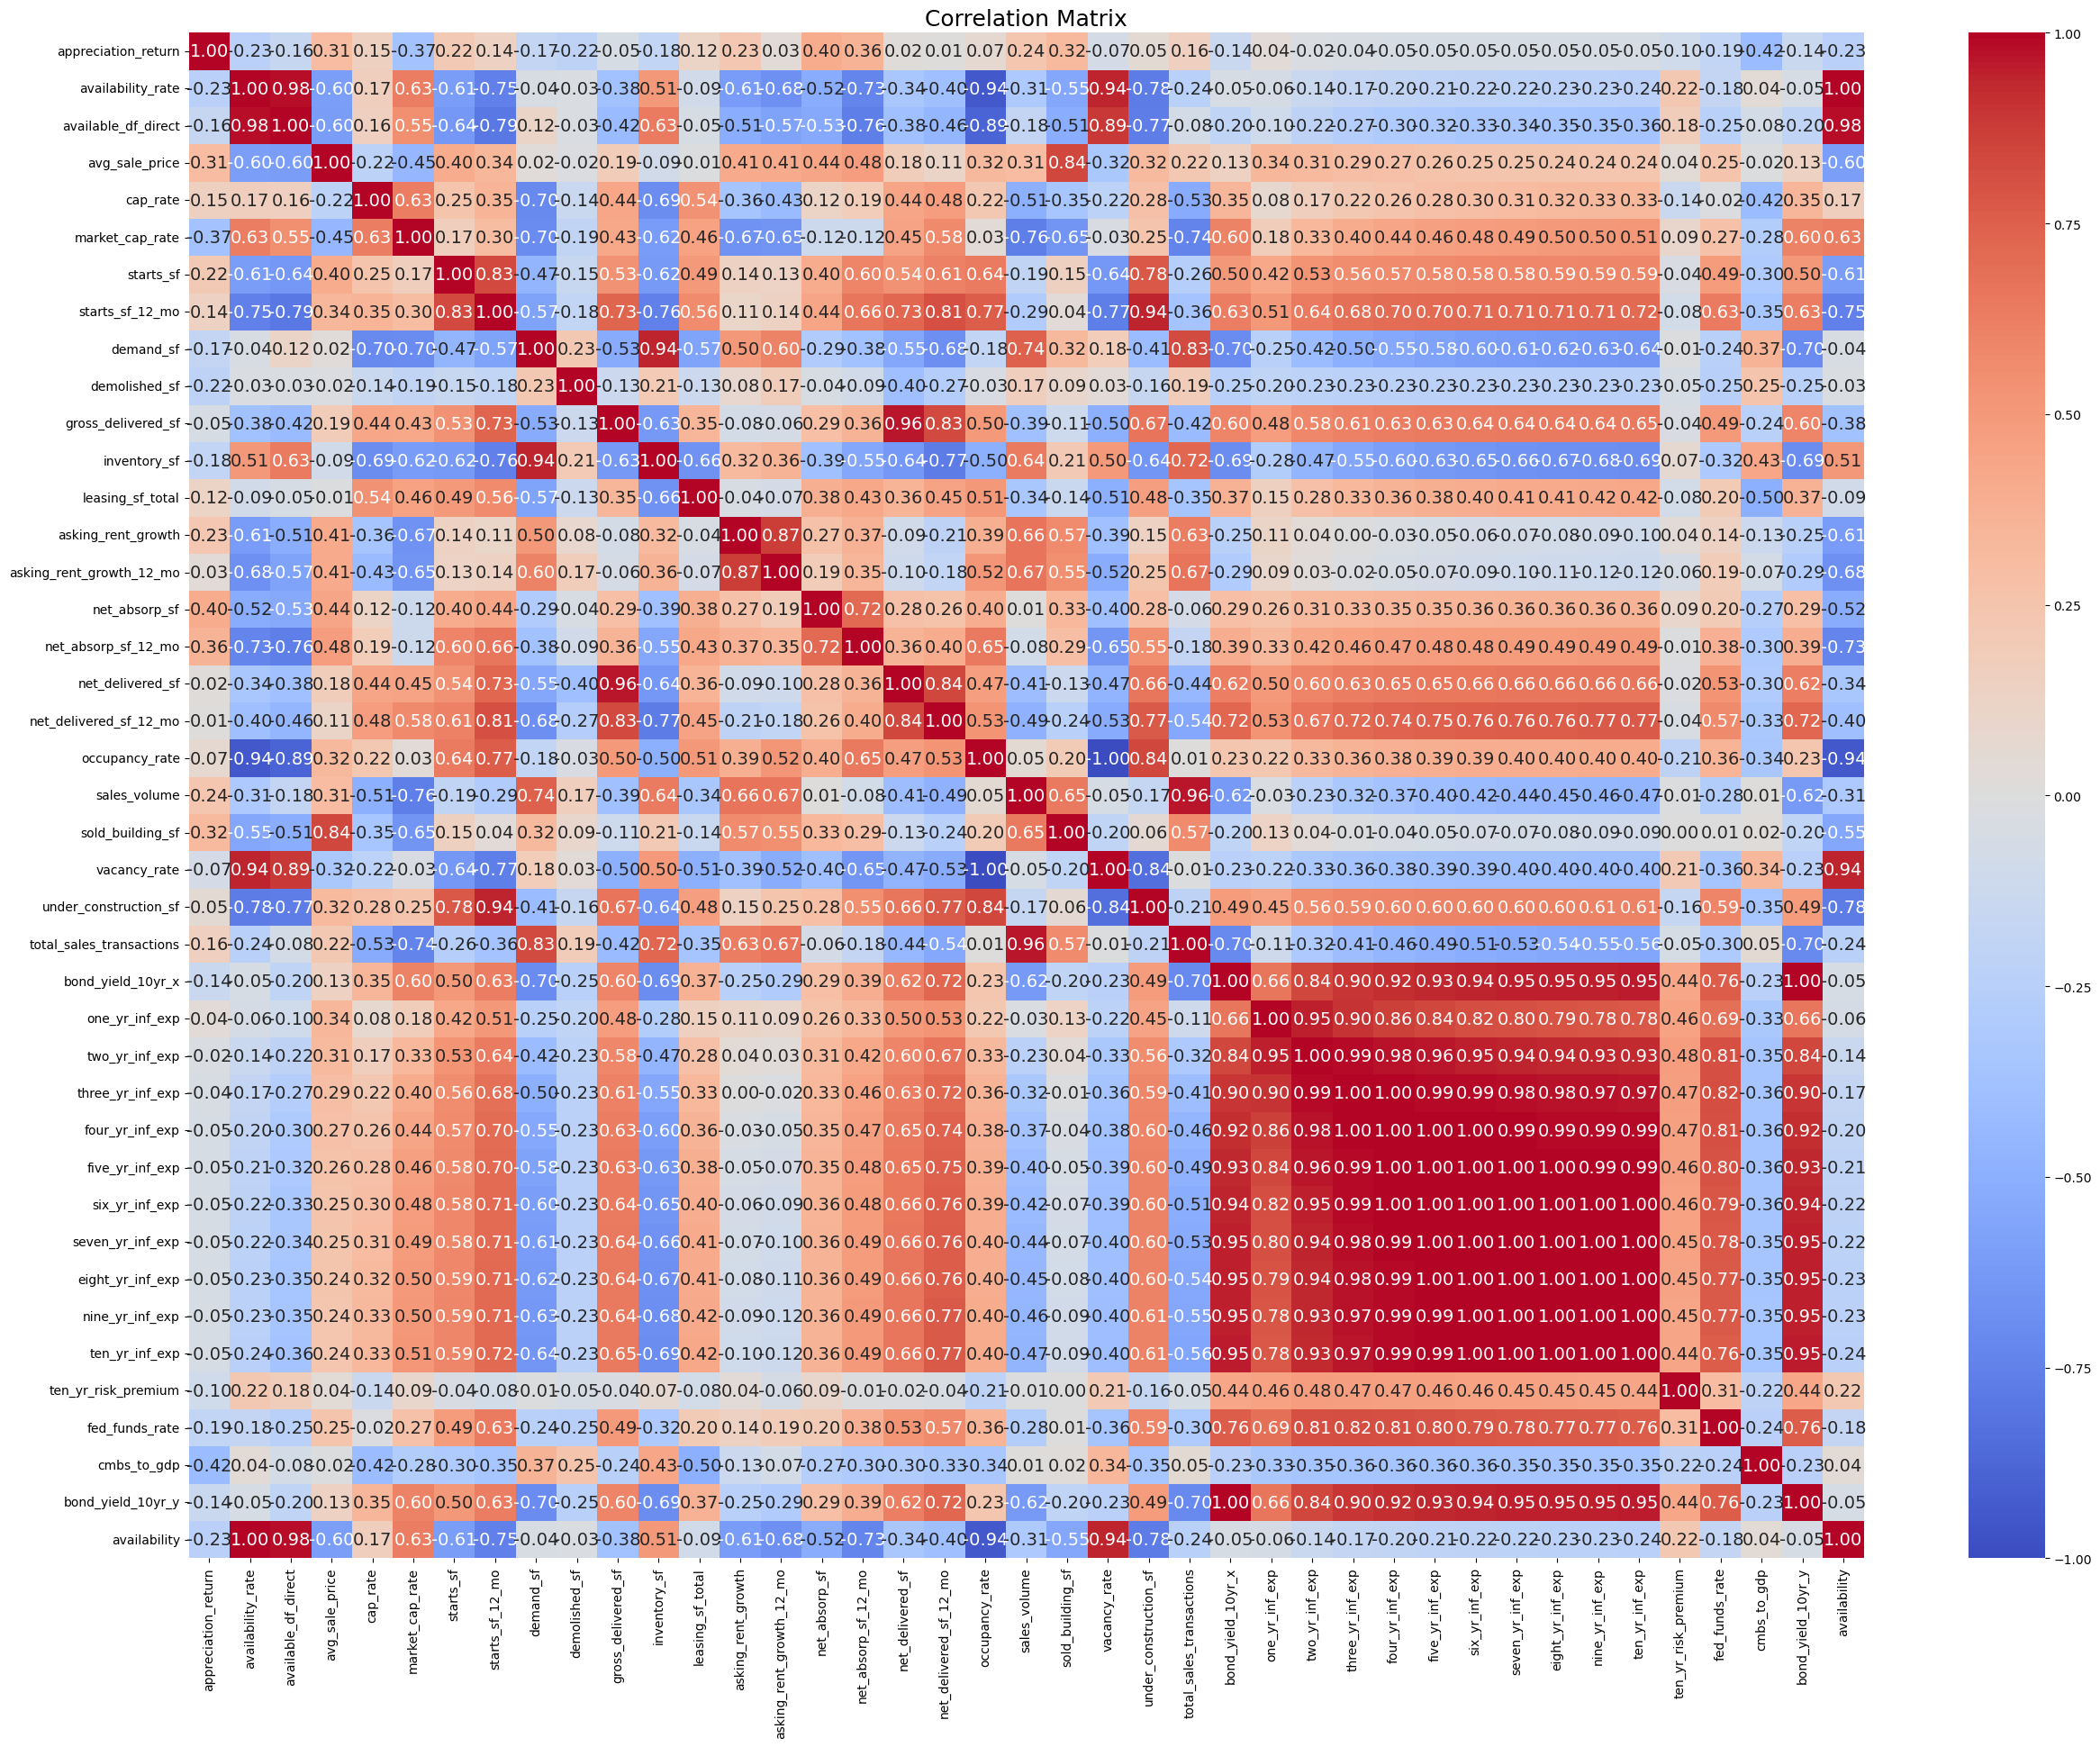

In [23]:
corr = cs_scaled.corr()
plt.figure(figsize=(30, 22))  # Increased size for better readability
sns.heatmap(corr, annot=True, annot_kws={"size": 14}, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix', fontsize=18)
plt.show()


In [24]:
#print the corrleations for variable market_cap_rate and list from highest to lowest correlation
corr_cmbs_to_gdp = corr['cmbs_to_gdp'].sort_values(ascending=False)
print(corr_cmbs_to_gdp)

cmbs_to_gdp                 1.000000
inventory_sf                0.431767
demand_sf                   0.366603
vacancy_rate                0.342103
demolished_sf               0.254957
total_sales_transactions    0.047757
availability_rate           0.041096
availability                0.041096
sold_building_sf            0.019712
sales_volume                0.008361
avg_sale_price             -0.015491
asking_rent_growth_12_mo   -0.074776
available_df_direct        -0.076715
asking_rent_growth         -0.127199
ten_yr_risk_premium        -0.217936
bond_yield_10yr_y          -0.234515
bond_yield_10yr_x          -0.234515
fed_funds_rate             -0.236679
gross_delivered_sf         -0.242649
net_absorp_sf              -0.265300
market_cap_rate            -0.275639
net_delivered_sf           -0.295052
net_absorp_sf_12_mo        -0.297353
starts_sf                  -0.304212
one_yr_inf_exp             -0.327453
net_delivered_sf_12_mo     -0.327898
occupancy_rate             -0.342103
u

### PCA Analysis

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [26]:
#check from NAs
cs_scaled.isnull().sum()

#drop the columns availability_rate available_df_direct, and availability
cs_scaled.drop(columns=['availability_rate', 'available_df_direct', 'availability'], inplace=True)

#forward fill the missing values
cs_scaled.fillna(method='ffill', inplace=True)

/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_6174/498923727.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cs_scaled.fillna(method='ffill', inplace=True)


In [27]:
cs_scaled.isnull().sum()


appreciation_return         0
avg_sale_price              0
cap_rate                    0
market_cap_rate             0
starts_sf                   0
starts_sf_12_mo             0
demand_sf                   0
demolished_sf               0
gross_delivered_sf          0
inventory_sf                0
leasing_sf_total            0
asking_rent_growth          0
asking_rent_growth_12_mo    0
net_absorp_sf               0
net_absorp_sf_12_mo         0
net_delivered_sf            0
net_delivered_sf_12_mo      0
occupancy_rate              0
sales_volume                0
sold_building_sf            0
vacancy_rate                0
under_construction_sf       0
total_sales_transactions    0
bond_yield_10yr_x           0
one_yr_inf_exp              0
two_yr_inf_exp              0
three_yr_inf_exp            0
four_yr_inf_exp             0
five_yr_inf_exp             0
six_yr_inf_exp              0
seven_yr_inf_exp            0
eight_yr_inf_exp            0
nine_yr_inf_exp             0
ten_yr_inf

In [28]:
cs_scaled.shape

(100, 38)

In [29]:
#export the data to a csv file
cs_scaled.to_csv('../data/preprocessed_df.csv')

In [24]:
pca = PCA(n_components=5)
pca.fit_transform(cs_scaled)

array([[ 1.41342710e+01,  1.69283788e+00, -2.55375159e+00,
         5.21922804e-01, -1.24294238e+00],
       [ 1.31842201e+01,  2.32519283e+00, -2.54083056e+00,
         4.51180353e-01, -1.64897354e+00],
       [ 1.14846290e+01,  1.71635824e-01, -2.60120305e+00,
        -2.01982725e+00, -2.06679207e+00],
       [ 1.11621900e+01,  1.12970190e+00, -2.88156469e+00,
        -1.11735447e+00, -8.81088428e-01],
       [ 7.64914553e+00, -1.14815479e+00, -3.37867620e+00,
        -1.74769608e+00, -1.58751747e+00],
       [ 8.50431770e+00, -1.23189297e+00, -2.50871365e+00,
        -1.04968983e+00, -1.11738035e+00],
       [ 7.61830467e+00, -2.66859711e+00, -1.22059285e+00,
        -1.25240666e+00, -1.00088259e+00],
       [ 5.88267003e+00, -3.14350931e+00, -2.15801243e+00,
        -6.64776117e-01, -6.20058228e-01],
       [ 6.72635346e+00, -3.84683303e+00, -7.29938416e-01,
         1.66103649e-01, -4.97203405e-01],
       [ 6.31170310e+00, -3.04084574e+00,  1.89384806e-01,
         1.29779579e+00

In [25]:
# Compute Factor Loadings
factor_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Use the column names from the scaled dataset as features
features = cs_scaled.columns

# Convert to DataFrame for better readability
factor_loading_df = pd.DataFrame(
    factor_loadings, 
    index=features,  # Keeping variable names
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Display Factor Loading Matrix
print(factor_loading_df)

                               PC1       PC2       PC3       PC4       PC5
appreciation_return       0.008837  0.320352 -0.294157  0.750420 -0.088483
avg_sale_price            0.236217  0.686955  0.086890  0.245291  0.464691
cap_rate                  0.445330 -0.380444 -0.511523  0.211091 -0.221044
market_cap_rate           0.554336 -0.720429 -0.137102 -0.155844 -0.202525
starts_sf                 0.690244  0.325014 -0.307563 -0.008262  0.124801
starts_sf_12_mo           0.838731  0.281282 -0.354080 -0.144356  0.071836
demand_sf                -0.723413  0.448180  0.350608 -0.316522 -0.124155
demolished_sf            -0.276579  0.090141  0.016089 -0.205455  0.251266
gross_delivered_sf        0.752970  0.017939 -0.232617 -0.246956  0.083746
inventory_sf             -0.802011  0.209341  0.483696 -0.183624 -0.088729
leasing_sf_total          0.531675 -0.018682 -0.506158  0.139263 -0.262762
asking_rent_growth       -0.109561  0.861192  0.065099 -0.037307 -0.177342
asking_rent_growth_12_mo 

### Checking how many components to us

In [128]:
explained_variance = pca.explained_variance_          # Eigenvalues (if standardized)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

In [129]:
n_kaiser = sum(explained_variance > 1)
print("Kaiser criterion suggests:", n_kaiser, "components")

Kaiser criterion suggests: 6 components


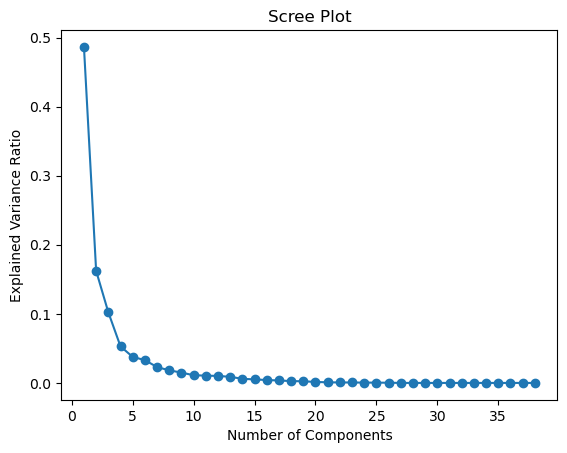

In [130]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

In [131]:
target_variance = 0.95
n_cumulative = np.argmax(cumulative_variance >= target_variance) + 1  # +1 for 1-based index
print(f"Components for {target_variance*100}% variance:", n_cumulative)

Components for 95.0% variance: 11


In [ ]:
cs = cs.set_index('period')  # Set time index


In [ ]:

# -------------------------------------------------
# 0. Variable Selection (ADD THIS SECTION)
# -------------------------------------------------
# List of key variables to include (customize based on domain knowledge)
selected_vars = [
    'appreciation_return', 
    'availability_rate',
    'available_df_direct', 
    'avg_sale_price', 
    'cap_rate', 
    'market_cap_rate',
    'starts_sf', 
    'starts_sf_12_mo', 
    'demand_sf', 
    'demolished_sf',
    'gross_delivered_sf', 
    'inventory_sf', 
    'leasing_sf_total',
    'asking_rent_growth', 
    'asking_rent_growth_12_mo', 
    'net_absorp_sf',
    'net_absorp_sf_12_mo', 
    'net_delivered_sf', 
    'net_delivered_sf_12_mo',
    'occupancy_rate', 'sales_volume',
    'sold_building_sf', 
    'vacancy_rate',
    'under_construction_sf', 
    'total_sales_transactions', 
    'fed_funds_rate',
    'bond_yield_10yr', 
    'availability'

]

# -------------------------------------------------
# 1. Data Preparation
# -------------------------------------------------
# Assuming df has 'period' column and selected variables
#df = df.set_index('period')  # Set time index
original_target = 'market_cap_rate'

# Filter dataframe to selected variables
df = df[selected_vars]

# -------------------------------------------------
# 2. Automated Preprocessing Pipeline (MODIFIED)
# -------------------------------------------------
def prepare_data(df, target_col, seasonal_period=8, selected_vars=None):
    """End-to-end preprocessing with target preservation"""
    
    # Filter to selected variables if provided
    if selected_vars:
        df = df[selected_vars]
    
    # Keep track of target through transformations
    target_transformations = []
    
    # A. Variance Stabilization
    cv_threshold = 0.5
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    
    for col in numeric_cols:
        series = df[col].dropna()
        if series.min() > 0:
            cv = series.std()/series.mean()
            if cv > cv_threshold:
                df[f'log_{col}'] = np.log(series)
                if col == target_col:
                    target_transformations.append(f'log_{col}')
            else:
                df[f'orig_{col}'] = series
                if col == target_col:
                    target_transformations.append(f'orig_{col}')
        else:
            df[f'orig_{col}'] = series
            if col == target_col:
                target_transformations.append(f'orig_{col}')
    
    # B. First Differencing
    transformed_cols = [c for c in df.columns if c.startswith(('log_', 'orig_'))]
    
    for col in transformed_cols:
        base_name = col.split('_', 1)[1]
        if adfuller(df[col].dropna())[1] > 0.05:
            df[f'd1_{base_name}'] = df[col].diff().dropna()
            if base_name == target_col:
                target_transformations.append(f'd1_{base_name}')
        else:
            df[f'd1_{base_name}'] = df[col]
    
    # C. Seasonal Differencing
    seasonal_cols = [c for c in df.columns if c.startswith('d1_')]
    
    for col in seasonal_cols:
        try:
            if adfuller(df[col].dropna())[1] > 0.05:
                df[f'sd{seasonal_period}_{col}'] = df[col].diff(seasonal_period).dropna()
        except:
            continue
    
    # D. Final Stationary Selection
    final_cols = []
    for col in df.columns:
        if col.startswith(('sd12_d1_', 'd1_')):
            if adfuller(df[col].dropna())[1] < 0.05:
                final_cols.append(col)
    
    # Ensure target is included
    final_target = target_transformations[-1]
    if final_target not in final_cols:
        final_cols.append(final_target)
    
    return df[final_cols].dropna()

# -------------------------------------------------
# 3. Execute Pipeline (MODIFIED)
# -------------------------------------------------
# Use either selected_vars or default to all variables
stationary_df = prepare_data(df, original_target, selected_vars=selected_vars)

# 4. Granger Causality Filtering
# -------------------------------------------------
def granger_filter(df, target_col, maxlag=2, p_threshold=0.05):
    """Select variables with Granger causal relationship"""
    candidate_vars = [col for col in df.columns if col != target_col]
    significant_vars = []
    
    for var in candidate_vars:
        try:
            test_result = grangercausalitytests(
                df[[target_col, var]], 
                maxlag=maxlag, 
                verbose=False
            )
            p_values = [test_result[i+1][0]['ssr_ftest'][1] for i in range(maxlag)]
            if min(p_values) < p_threshold:
                significant_vars.append(var)
        except:
            continue
    
    return df[[target_col] + significant_vars]

filtered_df = granger_filter(stationary_df, 
                            target_col=stationary_df.filter(like='appreciation_return').columns[0])

print(f"Final dataset shape: {filtered_df.shape}")
print(f"Variables: {filtered_df.columns.tolist()}")

# -------------------------------------------------
# 5. VAR Modeling
# -------------------------------------------------
def safe_var_model(df, maxlags=3):
    """VAR modeling with dimension checks"""
    T, k = df.shape
    max_feasible_lags = (T - 1) // (k + 1)  # Conservative estimate
    
    model = VAR(df)
    try:
        lag_results = model.select_order(maxlags=min(maxlags, max_feasible_lags))
        optimal_lag = lag_results.aic
    except:
        optimal_lag = 1
    
    return model.fit(optimal_lag)

var_model = safe_var_model(filtered_df)
print("\nVAR Model Summary:")
print(var_model.summary())

# -------------------------------------------------
# 6. Model Diagnostics
# -------------------------------------------------
print("\nResidual Autocorrelation Test:")
print("Durbin-Watson (want ~2):", durbin_watson(var_model.resid))

# Forecast visualization example
var_model.plot_forecast(steps=2)